# QP Trace Simulation Tutorial

This notebook walks through three things:

1. **Generating clean (noise-free) QP traces** with `QPSimulator` &mdash; the minimal standalone simulator that mirrors the QP/phonon path of `TraceSimulator` exactly.
2. **Using the `NoiseGenerator`** that ships with the project to draw colored Gaussian noise.
3. **Putting them together** &mdash; adding noise on top of a clean QP trace.

Prerequisites: `numpy`, `scipy`, `matplotlib`. The notebook expects to be run from the package root (`TraceSimulator/`).

In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt

# allow `from QPSimulator import QPSimulator` and `from NoiseGenerator import NoiseGenerator`
sys.path.insert(0, os.getcwd())

from QPSimulator import QPSimulator
# Import NoiseGenerator without triggering the full package __init__ (which pulls h5py etc.)
import importlib.util
_spec = importlib.util.spec_from_file_location("NoiseGenerator", os.path.join(os.getcwd(), "NoiseGenerator.py"))
_mod = importlib.util.module_from_spec(_spec); _spec.loader.exec_module(_mod)
NoiseGenerator = _mod.NoiseGenerator

rng = np.random.default_rng(0)

## 1. Clean QP traces with `QPSimulator`

The simulator builds a single-QP calorimetric response template &mdash; an exponential rise (τ_rise) followed by an exponential decay (τ_decay), peaking at `trigger_time` &mdash; and sums one copy per supplied arrival time.

Defaults match `TraceSimulator`: `f_s = 2.5×10⁵ Hz`, `trace_samples = 16384`, `τ_rise = 50 µs`, `τ_decay = 3 ms`, `trigger_time = 10% of the trace`.

Per-QP ADC amplitude:

$$A_\text{QP} = \text{gain}_\text{QE}\;\cdot\;E_\text{ADC}\;\cdot\;10^{-3}\;\cdot\;\text{meV}_\text{per QP}$$

(the $10^{-3}$ converts the $\sim$1 meV per phonon to eV).

In [2]:
sim = QPSimulator()
print(f"dt              = {sim.dt:g} ns")
print(f"trace duration  = {sim.trace_duration*1e-6:.2f} ms ({sim.trace_samples} samples)")
print(f"trigger_time    = {sim.trigger_time*1e-6:.2f} ms")
print(f"τ_rise / τ_decay = {sim.tau_rise*1e-3:g} µs / {sim.tau_decay*1e-6:g} ms")
print(f"per-QP amplitude= {sim.qp_amplitude:.4g} ADC counts")

t_ms = np.arange(sim.trace_samples) * sim.dt * 1e-6   # time axis in ms

dt              = 4000 ns
trace duration  = 65.54 ms (16384 samples)
trigger_time    = 6.55 ms
τ_rise / τ_decay = 50 µs / 3 ms
per-QP amplitude= 0.03 ADC counts


### 1.1 Single QP arriving at t = 0

A QP arriving at `t = 0` produces a peak at `trigger_time`. The peak height equals `qp_amplitude` (modulo discretization).

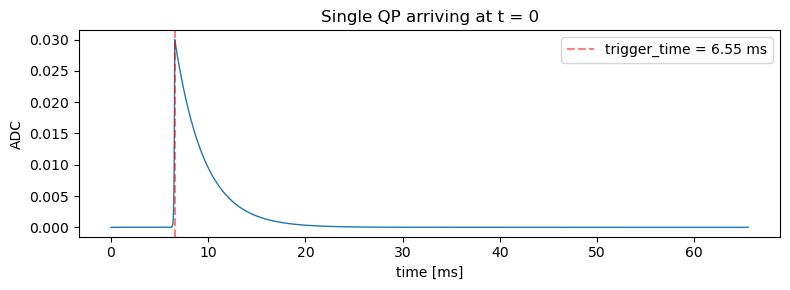

In [3]:
trace = sim.generate([0.0])

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_ms, trace, lw=1)
ax.axvline(sim.trigger_time*1e-6, color='r', ls='--', alpha=0.5, label=f'trigger_time = {sim.trigger_time*1e-6:.2f} ms')
ax.set_xlabel("time [ms]"); ax.set_ylabel("ADC")
ax.set_title("Single QP arriving at t = 0"); ax.legend()
fig.tight_layout()

### 1.2 Many QPs sampled from an arrival-time distribution

Real events have many QPs arriving at slightly different times because of ballistic propagation (≈1505–200 m/s in superfluid He-4). Whatever distribution you have for the arrival times — from a detector simulation, an analytic model, or a hand-picked function — just hand it to `generate(arrival_times)`.

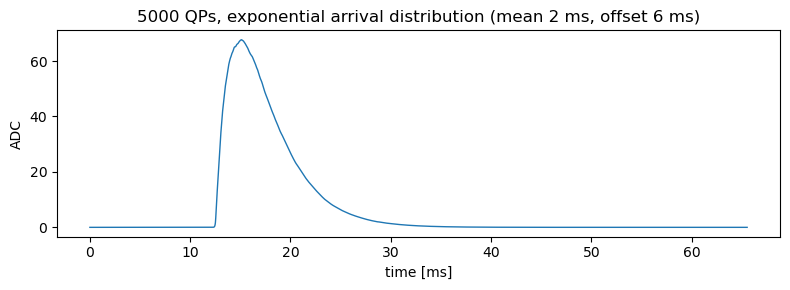

In [4]:
N_QP = 5_000
t_arr = rng.exponential(scale=2e6, size=N_QP) + 6e6   # ns; 2 ms tail starting at 6 ms
trace = sim.generate(t_arr)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_ms, trace, lw=1)
ax.set_xlabel("time [ms]"); ax.set_ylabel("ADC")
ax.set_title(f"{N_QP} QPs, exponential arrival distribution (mean 2 ms, offset 6 ms)")
fig.tight_layout()

### 1.3 Different arrival-time scenarios produce different pulse shapes

This is the "shift-manifold" sandbox &mdash; same QP count, varying arrival-time distribution. Notice both the peak position *and* the pulse shape change.

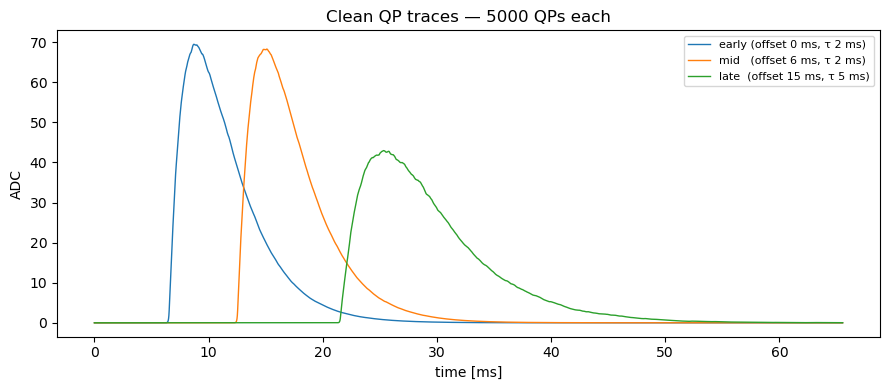

In [5]:
scenarios = {
    "early (offset 0 ms, τ 2 ms)":   rng.exponential(2e6, N_QP) + 0.0,
    "mid   (offset 6 ms, τ 2 ms)":   rng.exponential(2e6, N_QP) + 6e6,
    "late  (offset 15 ms, τ 5 ms)":  rng.exponential(5e6, N_QP) + 15e6,
}

fig, ax = plt.subplots(figsize=(9, 4))
for label, t in scenarios.items():
    ax.plot(t_ms, sim.generate(t), lw=1.0, label=label)
ax.set_xlabel("time [ms]"); ax.set_ylabel("ADC")
ax.set_title(f"Clean QP traces — {N_QP} QPs each"); ax.legend(fontsize=8)
fig.tight_layout()

## 2. The `NoiseGenerator`

`NoiseGenerator` produces a 1D array of colored Gaussian-like noise of length `N`. The constructor needs three keys in its config dict:

| key | meaning |
|---|---|
| `noise_type` | one of `'white' / 'pink' / 'blue' / 'violet' / 'brownian'`, **or** a path to a custom `.npy` PSD file |
| `noise_power` | the time-domain *variance*. So `std = sqrt(noise_power)` |
| `sampling_frequency` | Hz |

Spectral slopes (verified empirically): white = 0, pink = −1, blue = +1, violet = +2, brownian = −2.

In [6]:
cfg = dict(noise_type='pink', noise_power=25.0, sampling_frequency=2.5e5)
ng = NoiseGenerator(cfg)
noise = ng.generate_noise(sim.trace_samples)

print(f"noise_power    = {cfg['noise_power']}")
print(f"empirical std  = {noise.std():.3f}   (≈ sqrt(noise_power) = {np.sqrt(cfg['noise_power']):.3f})")
print(f"empirical mean = {noise.mean():+.4f}")

noise_power    = 25.0
empirical std  = 5.158   (≈ sqrt(noise_power) = 5.000)
empirical mean = -0.0000


### 2.1 Visualizing the five colors

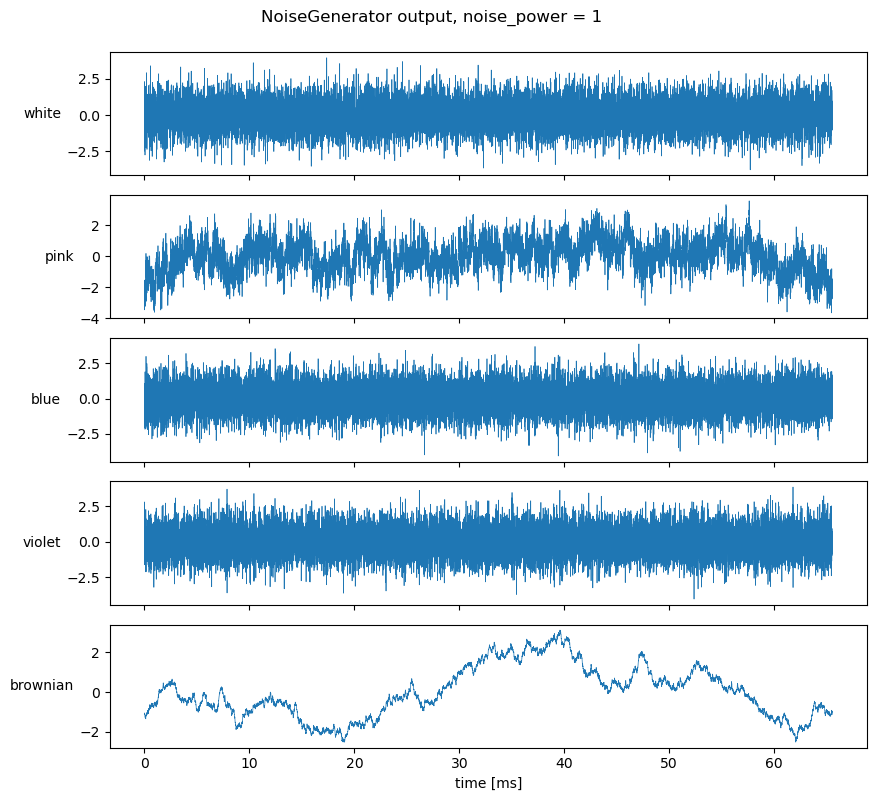

In [7]:
colors = ['white', 'pink', 'blue', 'violet', 'brownian']
fig, axes = plt.subplots(len(colors), 1, figsize=(9, 8), sharex=True)
for ax, c in zip(axes, colors):
    ng = NoiseGenerator(dict(noise_type=c, noise_power=1.0, sampling_frequency=2.5e5))
    n = ng.generate_noise(sim.trace_samples)
    ax.plot(t_ms, n, lw=0.5)
    ax.set_ylabel(c, rotation=0, ha='right', va='center')
axes[-1].set_xlabel("time [ms]")
fig.suptitle("NoiseGenerator output, noise_power = 1", y=0.995)
fig.tight_layout()

### 2.2 Verifying the PSD slopes

Average the periodogram over many traces and fit `log PSD` vs `log f`. Slopes should be (white, pink, blue, violet, brownian) = (0, −1, +1, +2, −2).

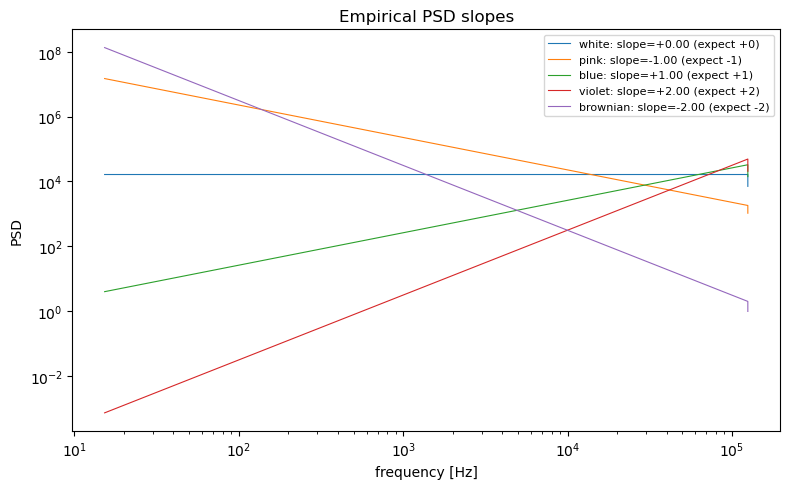

In [8]:
fs = sim.frequency
N  = sim.trace_samples
freq = np.fft.rfftfreq(N, d=1/fs)
mid = (freq > 5) & (freq < 5e4)

fig, ax = plt.subplots(figsize=(8, 5))
for c, expected in [('white', 0), ('pink', -1), ('blue', +1), ('violet', +2), ('brownian', -2)]:
    ng = NoiseGenerator(dict(noise_type=c, noise_power=1.0, sampling_frequency=fs))
    samples = np.stack([ng.generate_noise(N) for _ in range(50)])
    psd = (np.abs(np.fft.rfft(samples, axis=1))**2).mean(axis=0)
    slope, _ = np.polyfit(np.log(freq[mid]), np.log(psd[mid]), 1)
    ax.loglog(freq[1:], psd[1:], lw=0.8, label=f"{c}: slope={slope:+.2f} (expect {expected:+d})")
ax.set_xlabel("frequency [Hz]"); ax.set_ylabel("PSD"); ax.legend(fontsize=8); ax.set_title("Empirical PSD slopes")
fig.tight_layout()

## 3. Putting it together: noisy QP traces

Generate a clean QP trace, draw a noise realization with the same length, sum them. Quantize to integer ADC counts if you want to match the digitizer.

In [9]:
# ---- 1. clean QP trace -------------------------------------------------
N_QP  = 5_000
t_arr = rng.exponential(scale=2e6, size=N_QP) + 6e6     # ns
clean = sim.generate(t_arr)

# ---- 2. noise realization ---------------------------------------------
ng    = NoiseGenerator(dict(noise_type='pink', noise_power=10.0, sampling_frequency=sim.frequency))
noise = ng.generate_noise(sim.trace_samples)

# ---- 3. combine --------------------------------------------------------
noisy = clean + noise
noisy_int = noisy.astype(int)   # if you want integer ADC, like TraceSimulator

# diagnostics
snr = clean.max() / noise.std()
print(f"clean peak  : {clean.max():7.2f} ADC")
print(f"noise std   : {noise.std():7.2f} ADC")
print(f"peak / std  : {snr:7.2f}   (rough single-sample SNR)")

clean peak  :   67.77 ADC
noise std   :    3.26 ADC
peak / std  :   20.78   (rough single-sample SNR)


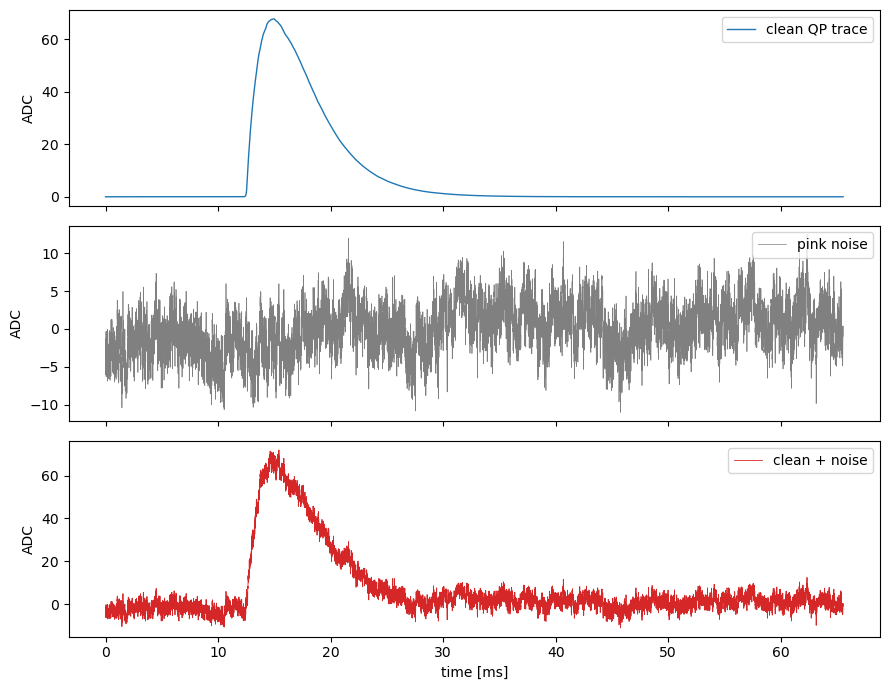

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(9, 7), sharex=True)
axes[0].plot(t_ms, clean, lw=1.0, color='C0', label='clean QP trace')
axes[1].plot(t_ms, noise, lw=0.5, color='gray', label='pink noise')
axes[2].plot(t_ms, noisy, lw=0.6, color='C3', label='clean + noise')
for ax in axes:
    ax.legend(loc='upper right'); ax.set_ylabel('ADC')
axes[-1].set_xlabel('time [ms]')
fig.tight_layout()

### 3.1 Sweeping noise level vs SNR

Same clean trace, varying `noise_power`.

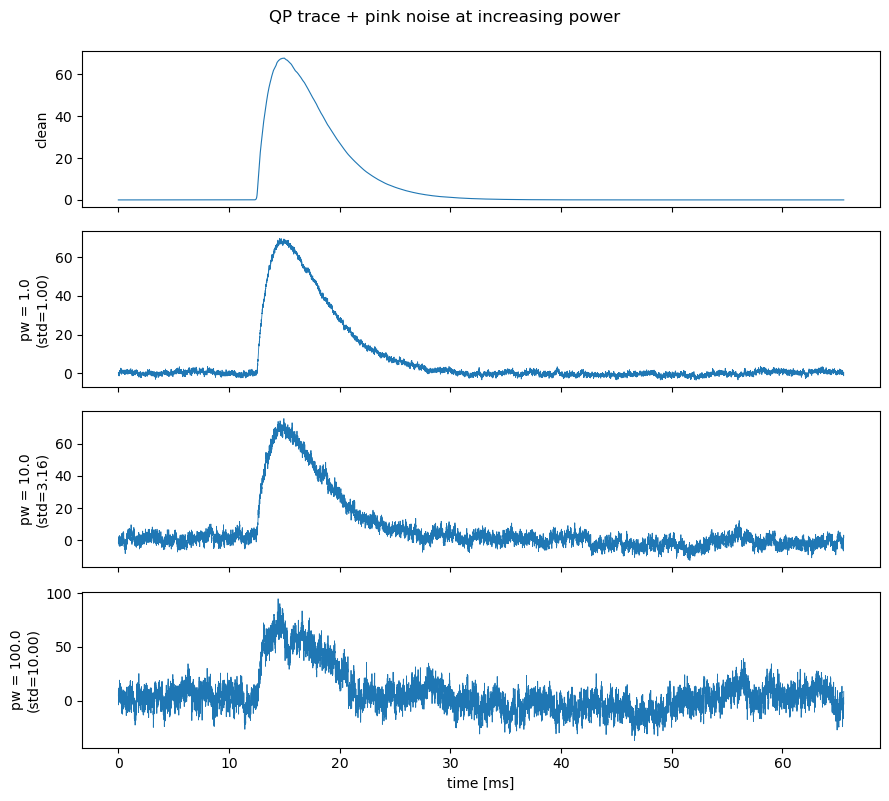

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(9, 8), sharex=True)
for ax, pw in zip(axes, [0.0, 1.0, 10.0, 100.0]):
    if pw == 0.0:
        ax.plot(t_ms, clean, lw=0.8, color='C0')
        ax.set_ylabel('clean')
    else:
        ng = NoiseGenerator(dict(noise_type='pink', noise_power=pw, sampling_frequency=sim.frequency))
        ax.plot(t_ms, clean + ng.generate_noise(sim.trace_samples), lw=0.6)
        ax.set_ylabel(f'pw = {pw}\n(std={np.sqrt(pw):.2f})')
axes[-1].set_xlabel('time [ms]')
fig.suptitle('QP trace + pink noise at increasing power', y=0.995)
fig.tight_layout()

### 3.2 Generating an ensemble of (clean, noisy) pairs

Convenient pattern for training/evaluation datasets: pair each clean trace with an independent noise draw.

clean_ds shape: (20, 16384)
noisy_ds shape: (20, 16384)


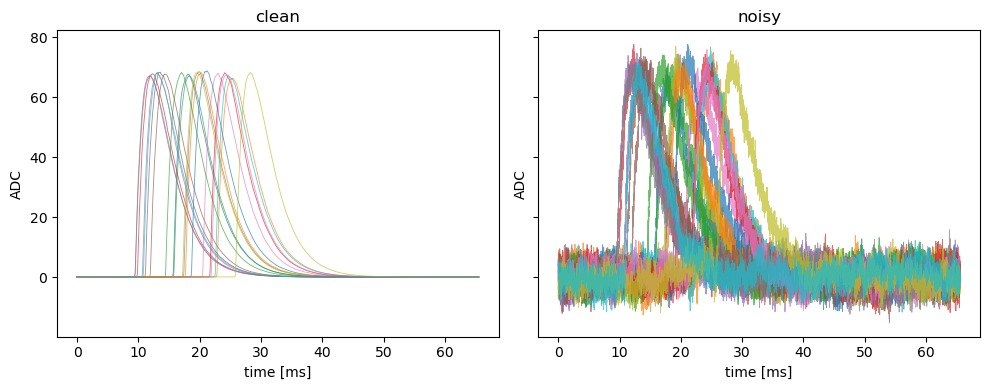

In [12]:
n_events  = 20
ng        = NoiseGenerator(dict(noise_type='pink', noise_power=10.0, sampling_frequency=sim.frequency))

clean_ds  = np.empty((n_events, sim.trace_samples))
noisy_ds  = np.empty((n_events, sim.trace_samples))
offsets   = rng.uniform(2e6, 20e6, n_events)   # different per-event arrival-time offsets (ns)

for k in range(n_events):
    t_arr        = rng.exponential(scale=2e6, size=N_QP) + offsets[k]
    clean_ds[k]  = sim.generate(t_arr)
    noisy_ds[k]  = clean_ds[k] + ng.generate_noise(sim.trace_samples)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
axes[0].plot(t_ms, clean_ds.T, lw=0.6, alpha=0.7); axes[0].set_title('clean')
axes[1].plot(t_ms, noisy_ds.T, lw=0.6, alpha=0.7); axes[1].set_title('noisy')
for ax in axes:
    ax.set_xlabel('time [ms]'); ax.set_ylabel('ADC')
fig.tight_layout()
print(f"clean_ds shape: {clean_ds.shape}")
print(f"noisy_ds shape: {noisy_ds.shape}")

## Recap

- **`QPSimulator(...)`** — build once with your digitizer/template parameters.
- **`sim.generate(arrival_times_ns)`** — hand it a 1D array of per-QP arrival times in ns; get back a clean trace of shape `(trace_samples,)` in float ADC counts.
- **`NoiseGenerator({'noise_type': 'pink', 'noise_power': σ², 'sampling_frequency': f_s})`** — build once; `ng.generate_noise(N)` returns an independent realization each call.
- **Compose**: `noisy = sim.generate(t_arr) + ng.generate_noise(sim.trace_samples)` (then `.astype(int)` if you want digitized).

The clean-trace path is bit-equivalent (to one float64 ulp) with the QP/phonon path of the full `TraceSimulator`.